# The goal of this project is to analyze Climate Change Impact on Agriculture and uncover patterns, trends, and relationships between variables.

Dataset used: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture/data

This dataset contains records of climate variables and agricultural outcomes across countries and years. It includes features such as year, country/region, average temperature, precipitation, CO₂ emissions, extreme weather events, irrigation access, pesticide use,fetilizer used, soil health index, and crop yield. The goal of this analysis is to explore how temperature, rainfall, and other climate factors affect crop production, and to see how these relationships differ across countries and over time.

## Exploratory Data Analysis:

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

file_path = r'C:\Users\48668\Documents\python zadanka\etl_cwiczenia 2\etl_cwiczenia\data\climate_change_impact_on_agriculture_2024.csv'
data = pd.read_csv(file_path)

data.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


In [25]:
data.sample(3)

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
7939,2017,Australia,New South Wales,Vegetables,9.10,204.65,16.65,1.629,9,63.09,12.63,96.01,58.63,Crop Rotation,452.86
7564,1993,India,Tamil Nadu,Sugarcane,16.35,1511.86,5.37,4.190,8,10.61,42.10,77.86,70.39,Crop Rotation,1229.29
8052,2019,Brazil,North,Sugarcane,34.62,1824.83,24.47,3.285,7,22.40,15.70,47.09,32.99,Organic Farming,753.96


In [26]:
data.tail()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
9995,2022,France,Nouvelle-Aquitaine,Cotton,30.48,685.93,17.64,3.033,9,27.56,41.96,10.95,43.41,No Adaptation,1483.06
9996,1999,Australia,Queensland,Soybeans,9.53,2560.38,10.68,2.560,4,77.02,5.45,82.32,59.39,No Adaptation,829.61
9997,2000,Argentina,Patagonia,Coffee,31.92,357.76,26.01,1.161,10,78.53,11.94,26.00,41.46,Water Management,155.99
9998,1996,Brazil,Southeast,Soybeans,13.95,1549.52,17.31,3.348,2,42.65,44.71,25.07,75.10,Crop Rotation,1613.90
9999,2015,China,South,Corn,11.78,1676.25,5.34,3.710,5,46.41,48.28,98.27,59.38,Water Management,453.14


In [27]:
print(f'Number of columns: {data.shape[1]}\n Number of rows: {data.shape[0]:,}')

Number of columns: 15
 Number of rows: 10,000


In [28]:
print(f'Columns in the dataset: {data.columns}')

Columns in the dataset: Index(['Year', 'Country', 'Region', 'Crop_Type', 'Average_Temperature_C',
       'Total_Precipitation_mm', 'CO2_Emissions_MT', 'Crop_Yield_MT_per_HA',
       'Extreme_Weather_Events', 'Irrigation_Access_%',
       'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA',
       'Soil_Health_Index', 'Adaptation_Strategies',
       'Economic_Impact_Million_USD'],
      dtype='str')


In [29]:
numerical_columns = data.select_dtypes((int,float)).columns
numerical_columns

Index(['Year', 'Average_Temperature_C', 'Total_Precipitation_mm',
       'CO2_Emissions_MT', 'Crop_Yield_MT_per_HA', 'Extreme_Weather_Events',
       'Irrigation_Access_%', 'Pesticide_Use_KG_per_HA',
       'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index',
       'Economic_Impact_Million_USD'],
      dtype='str')

In [30]:
text_columns = data.select_dtypes(str).columns
text_columns

Index(['Country', 'Region', 'Crop_Type', 'Adaptation_Strategies'], dtype='str')

In [31]:
data.dtypes

Year                             int64
Country                            str
Region                             str
Crop_Type                          str
Average_Temperature_C          float64
Total_Precipitation_mm         float64
CO2_Emissions_MT               float64
Crop_Yield_MT_per_HA           float64
Extreme_Weather_Events           int64
Irrigation_Access_%            float64
Pesticide_Use_KG_per_HA        float64
Fertilizer_Use_KG_per_HA       float64
Soil_Health_Index              float64
Adaptation_Strategies              str
Economic_Impact_Million_USD    float64
dtype: object

In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  str    
 2   Region                       10000 non-null  str    
 3   Crop_Type                    10000 non-null  str    
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strategies       

In [33]:
print(data.isna().sum())

Year                           0
Country                        0
Region                         0
Crop_Type                      0
Average_Temperature_C          0
Total_Precipitation_mm         0
CO2_Emissions_MT               0
Crop_Yield_MT_per_HA           0
Extreme_Weather_Events         0
Irrigation_Access_%            0
Pesticide_Use_KG_per_HA        0
Fertilizer_Use_KG_per_HA       0
Soil_Health_Index              0
Adaptation_Strategies          0
Economic_Impact_Million_USD    0
dtype: int64


- The dataset contains 10,000 records and 15 columns, including both numerical and categorical variables.
- There are no missing values in the dataset.
- Overall, the dataset appears clean, well-structured, and ready for analysis.

In [34]:
data.describe() 

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2007.088700,15.241299,1611.663834,15.246608,2.240017,4.980900,55.248332,24.955735,49.973708,64.901278,674.269658
std,10.084245,11.466955,805.016815,8.589423,0.998342,3.165808,25.988305,14.490962,28.711027,20.195882,414.591431
min,1990.000000,-4.990000,200.150000,0.500000,0.450000,0.000000,10.010000,0.000000,0.010000,30.000000,47.840000
25%,1999.000000,5.430000,925.697500,7.760000,1.449000,2.000000,32.677500,12.527500,25.390000,47.235000,350.545000
50%,2007.000000,15.175000,1611.160000,15.200000,2.170000,5.000000,55.175000,24.930000,49.635000,64.650000,583.920000
75%,2016.000000,25.340000,2306.997500,22.820000,2.930000,8.000000,77.582500,37.470000,74.825000,82.472500,917.505000
max,2024.000000,35.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,2346.470000


Expanding the dataset to include continent, longitude, and latitude:

In [35]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)

world['Latitude'] = world.geometry.centroid.y
world['Longitude'] = world.geometry.centroid.x

world.head()

C:\Users\48668\AppData\Local\Temp\ipykernel_14024\1750986915.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world['Latitude'] = world.geometry.centroid.y
C:\Users\48668\AppData\Local\Temp\ipykernel_14024\1750986915.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world['Longitude'] = world.geometry.centroid.x


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,Latitude,Longitude
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",-17.316309,163.853165
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",-6.257732,34.752990
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",24.291173,-12.137831
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",61.469076,-98.142381
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",45.705628,-112.599436


In [36]:
# I have found out that there is 'USA' in data df and 'United States of America' in world df
mapping = {
    'USA': 'United States of America'
}

data['Country'] = data['Country'].replace(mapping)

In [37]:
data = data.merge(
    world[['ADMIN','CONTINENT','Latitude','Longitude']],
    left_on='Country',
    right_on='ADMIN',
    how='left')

data.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,ADMIN,CONTINENT,Latitude,Longitude
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13,India,Asia,22.925006,79.593704
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22,China,Asia,36.555067,103.883612
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96,France,Europe,42.460704,-2.876697
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32,Canada,North America,61.469076,-98.142381
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72,India,Asia,22.925006,79.593704


In [38]:
data = data.rename(columns={'CONTINENT': 'Continent'})
data = data.drop(columns='ADMIN')

In [39]:
data.head(2)

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Continent,Latitude,Longitude
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13,Asia,22.925006,79.593704
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22,Asia,36.555067,103.883612


In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  str    
 2   Region                       10000 non-null  str    
 3   Crop_Type                    10000 non-null  str    
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strategies       

## Text Columns Analysis

In [41]:
print('Years of analysis:')
unique_years = data['Year'].unique()
print(np.sort(unique_years))
print(f'Numbers of years covered by analysis: {len(unique_years)}')
print(f'First year: {unique_years.min()}')
print(f'Last year: {unique_years.max()}')

Years of analysis:
[1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024]
Numbers of years covered by analysis: 35
First year: 1990
Last year: 2024


In [42]:
print('Countries examined:')
unique_countries = data['Country'].unique()
print(unique_countries)
print(f'\nNumber of countries: {len(unique_countries)}')

Countries examined:
<StringArray>
[                   'India',                    'China',
                   'France',                   'Canada',
 'United States of America',                'Argentina',
                'Australia',                  'Nigeria',
                   'Russia',                   'Brazil']
Length: 10, dtype: str

Number of countries: 10


In [43]:
print('Regions examined:')
unique_regions = list(data['Region'].unique())
print(unique_regions)
print(f'\nNumber of regions: {len(unique_regions)}')

Regions examined:
['West Bengal', 'North', 'Ile-de-France', 'Prairies', 'Tamil Nadu', 'Midwest', 'Northeast', 'New South Wales', 'Punjab', 'North West', 'South East', 'Grand Est', 'Northwestern', 'Siberian', 'Northwest', 'Victoria', 'Nouvelle-Aquitaine', 'South', 'Quebec', 'Southeast', 'Ontario', 'East', 'Pampas', 'Western Australia', 'Volga', 'Maharashtra', 'Provence-Alpes-Cote d’Azur', 'West', 'Central', 'North Central', 'Patagonia', 'Queensland', 'South West', 'British Columbia']

Number of regions: 34


<Axes: title={'center': 'Distribution of Data by Continent'}>

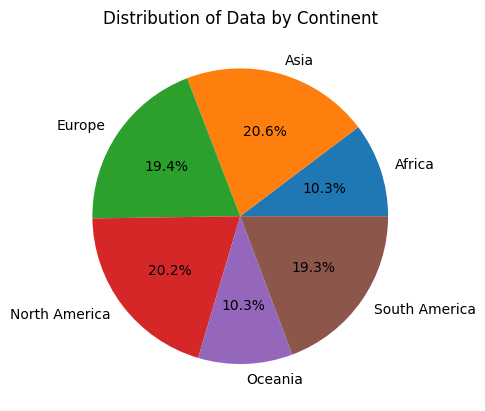

In [44]:
data.groupby('Continent')['Continent'].value_counts().plot(kind='pie',autopct='%1.1f%%', title = 'Distribution of Data by Continent')

Data is unevenly distributed, the most data is for North America and the least for Africa and Oceania.

In [45]:
crop_types =  list(data['Crop_Type'].unique())
print(f'Number of crops: {len(crop_types)}')
print(crop_types)

Number of crops: 10
['Corn', 'Wheat', 'Coffee', 'Sugarcane', 'Fruits', 'Rice', 'Barley', 'Vegetables', 'Soybeans', 'Cotton']


In [46]:
countries_crop_data = pd.DataFrame(data.groupby("Country")["Crop_Type"].unique())
countries_crop_data['Number of different crops'] = len('Crop_Type')
countries_crop_data

,Crop_Type,Number of different crops
Country,,
Argentina,"[Fruits, Coffee, Soybeans, Rice, Cotton, Corn,...",9
Australia,"[Rice, Coffee, Wheat, Sugarcane, Barley, Veget...",9
Brazil,"[Barley, Rice, Corn, Sugarcane, Fruits, Cotton...",9
Canada,"[Coffee, Fruits, Cotton, Soybeans, Barley, Sug...",9
China,"[Corn, Rice, Vegetables, Barley, Sugarcane, Wh...",9
France,"[Wheat, Coffee, Soybeans, Vegetables, Cotton, ...",9
India,"[Corn, Sugarcane, Wheat, Soybeans, Vegetables,...",9
Nigeria,"[Barley, Sugarcane, Soybeans, Coffee, Rice, Wh...",9
Russia,"[Vegetables, Cotton, Rice, Wheat, Fruits, Corn...",9


- The dataset is perfectly balanced in terms of crop diversity.
- There are no countries with missing categories.
- All countries have an identical set of crop types.

<Axes: title={'center': 'Adaptation Strategies'}>

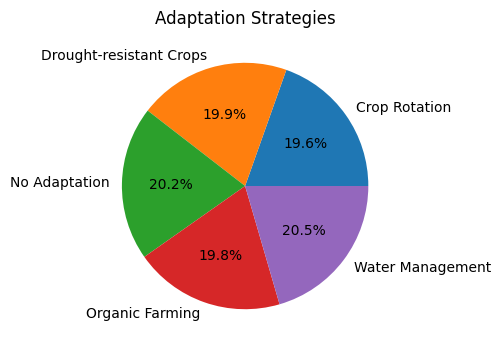

In [47]:
data.groupby('Adaptation_Strategies')['Adaptation_Strategies'].value_counts().plot(kind='pie', figsize=(12,4), title ='Adaptation Strategies', autopct='%1.1f%%')

When it comes to Adaptation Stategies, data is well balanced.

In [48]:
print('Adaptation Strategies per Continent:')
pd.crosstab(data['Continent'], data['Adaptation_Strategies'])

Adaptation Strategies per Continent:


Adaptation_Strategies,Crop Rotation,Drought-resistant Crops,No Adaptation,Organic Farming,Water Management
Continent,,,,,
Africa,203,187,225,210,204
Asia,397,397,442,410,410
Europe,394,372,378,407,388
North America,393,438,404,372,409
Oceania,212,214,182,203,221
South America,358,387,393,373,417


- No Adaptation is common in Africa and Asia,
- Water Management is the dominant strategy in South America and Oceania,
- Organic Farming is most common in Europe, 
- Drought-resistant Crops are more common in North America.

## Numerical Columns Analysis

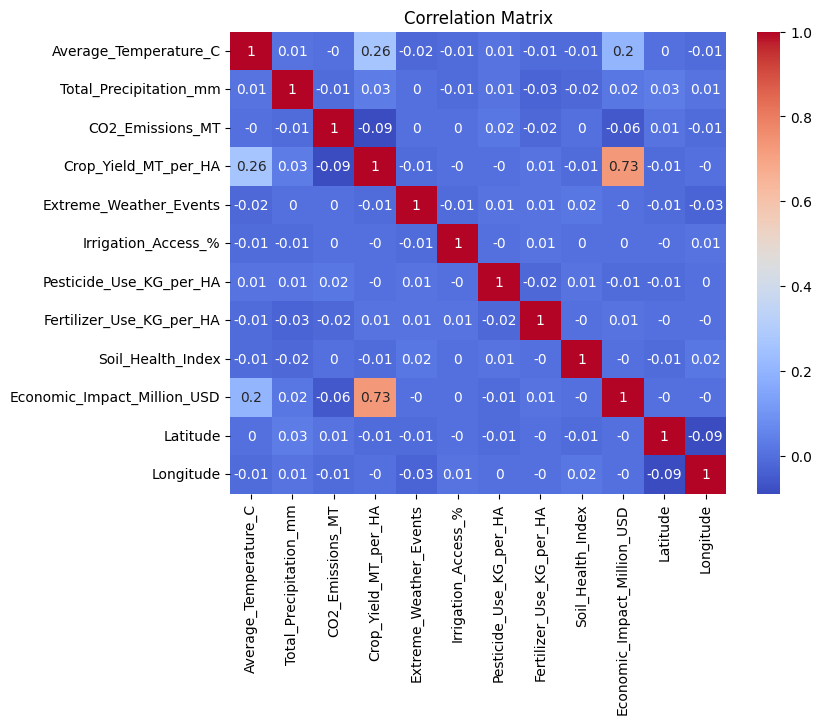

In [49]:
corr = data.select_dtypes(include=['number']).drop(columns=['Year']).corr().round(2)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

There is a strong correlation between yields and economic impact, which makes sense. No other significant correlation was observed.

In [50]:
q1_avg_temp = data['Average_Temperature_C'].quantile(0.25)
q3_avg_temp  = data['Average_Temperature_C'].quantile(0.75)
iqr_avg_temp  = q3_avg_temp  - q1_avg_temp 
outliers_avg_temp = data[(data['Average_Temperature_C'] < q1_avg_temp  - 1.5*iqr_avg_temp ) 
                   | (data['Average_Temperature_C'] > q3_avg_temp  + 1.5*iqr_avg_temp)]
print(outliers_avg_temp)

Empty DataFrame
Columns: [Year, Country, Region, Crop_Type, Average_Temperature_C, Total_Precipitation_mm, CO2_Emissions_MT, Crop_Yield_MT_per_HA, Extreme_Weather_Events, Irrigation_Access_%, Pesticide_Use_KG_per_HA, Fertilizer_Use_KG_per_HA, Soil_Health_Index, Adaptation_Strategies, Economic_Impact_Million_USD, Continent, Latitude, Longitude]
Index: []


<Axes: >

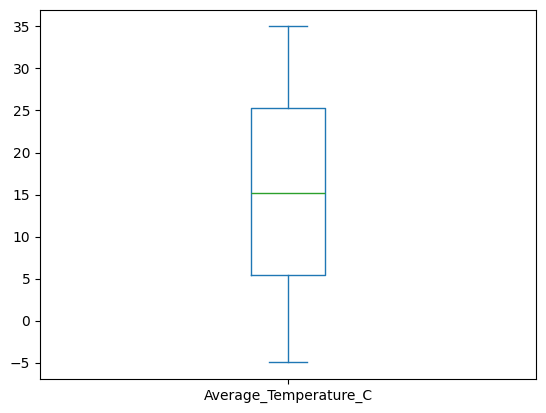

In [51]:
data['Average_Temperature_C'].plot(kind='box')

There are no outstanding values in 'Average_Temperature_C' column.

<Axes: title={'center': 'Average Temperature - Global Trends Over the Years'}, xlabel='Year'>

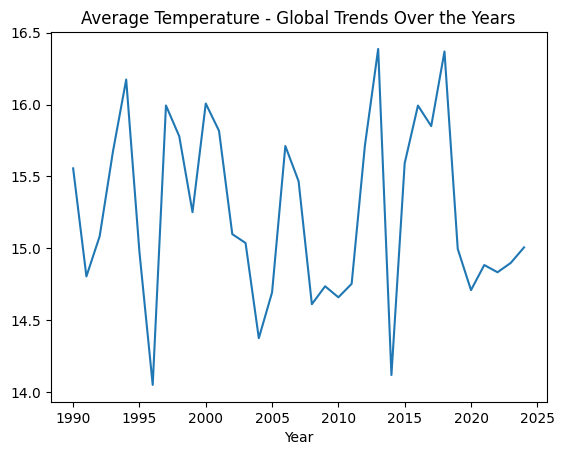

In [52]:
data.groupby('Year')['Average_Temperature_C'].mean().plot(kind='line', title='Average Temperature - Global Trends Over the Years')

The temperature has fluctuated between 14 and 16 degrees Celsius over the years, with the most recent data showing ca. 15 degrees Celsius. It's clear that there was a downward trend until 2020, which is surprising since all media have been talking about significant global warming.

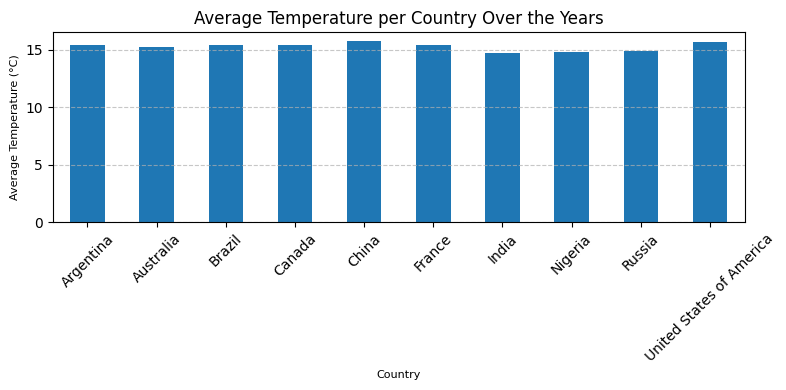

In [53]:
avg_temp = data.groupby('Country')['Average_Temperature_C'].mean()
avg_temp.plot(kind='bar', figsize=(8,4), title='Average Temperature per Country Over the Years')
plt.xlabel('Country', fontsize=8)
plt.ylabel('Average Temperature (°C)', fontsize=8)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Average temperatures between countries (across all the yeras ) do not differ much.

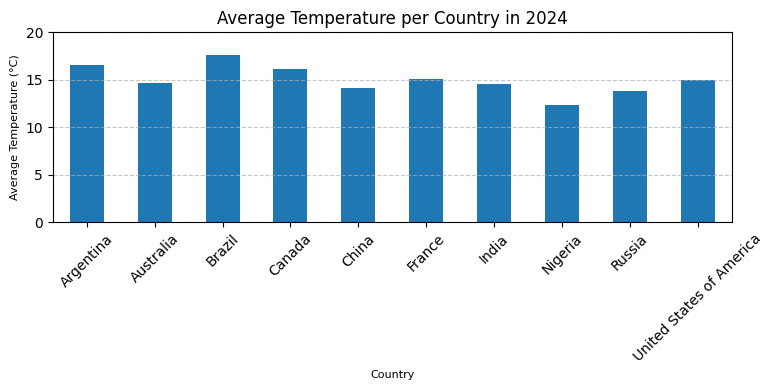

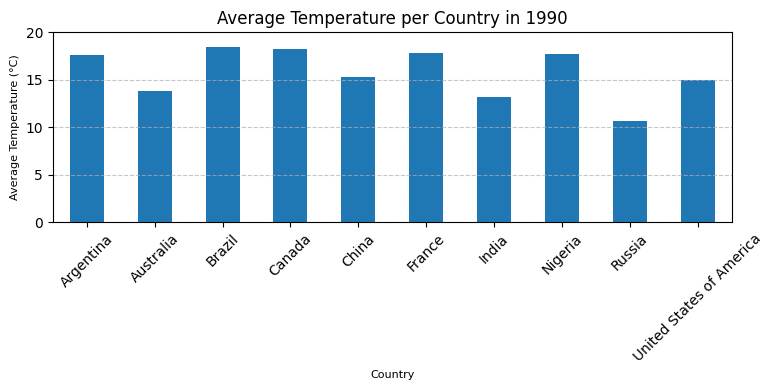

In [54]:
max_year = data['Year'].max()
min_year = data['Year'].min()

avg_temp_max_year = data[data['Year']==max_year].groupby('Country')['Average_Temperature_C'].mean()
avg_temp_max_year.plot(kind='bar', figsize=(8,4), title=f'Average Temperature per Country in {max_year}')
plt.xlabel('Country', fontsize=8)
plt.ylabel('Average Temperature (°C)', fontsize=8)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(top = 20)
plt.tight_layout()
plt.show()

avg_temp_min_year = data[data['Year']==min_year].groupby('Country')['Average_Temperature_C'].mean()
avg_temp_min_year.plot(kind='bar', figsize=(8,4), title=f'Average Temperature per Country in {min_year}')
plt.xlabel('Country', fontsize=8)
plt.ylabel('Average Temperature (°C)', fontsize=8)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(top = 20)
plt.tight_layout()
plt.show()

Comparing the first and last year of data, we see that for some countries, the average temperature has decreased over the years, such as in Brazil, Canada, and China. However, in France, Russia, and India, there is a growth in the average temperature.

In [55]:
q1_precipitation = data['Total_Precipitation_mm'].quantile(0.25)
q3_precipitation  = data['Total_Precipitation_mm'].quantile(0.75)
iqr_precipitation  = q3_precipitation  - q1_precipitation 
outliers_precipitation = data[(data['Total_Precipitation_mm'] < q1_precipitation  - 1.5*iqr_precipitation) 
                   | (data['Total_Precipitation_mm'] > q3_precipitation  + 1.5*iqr_precipitation)]
print(outliers_precipitation)

Empty DataFrame
Columns: [Year, Country, Region, Crop_Type, Average_Temperature_C, Total_Precipitation_mm, CO2_Emissions_MT, Crop_Yield_MT_per_HA, Extreme_Weather_Events, Irrigation_Access_%, Pesticide_Use_KG_per_HA, Fertilizer_Use_KG_per_HA, Soil_Health_Index, Adaptation_Strategies, Economic_Impact_Million_USD, Continent, Latitude, Longitude]
Index: []


<Axes: >

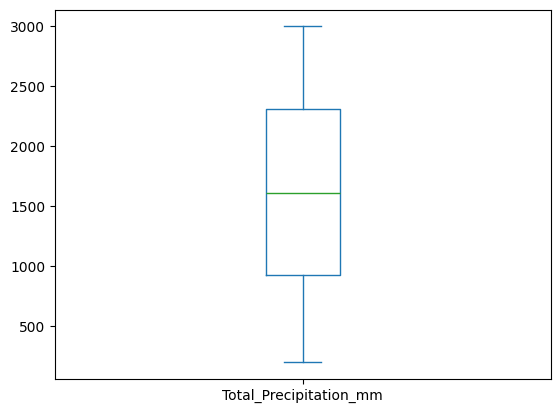

In [56]:
data['Total_Precipitation_mm'].plot(kind='box')

No outliers here as well

<Axes: title={'center': 'Average Precipitation - Global Trends Over the Years'}, xlabel='Year'>

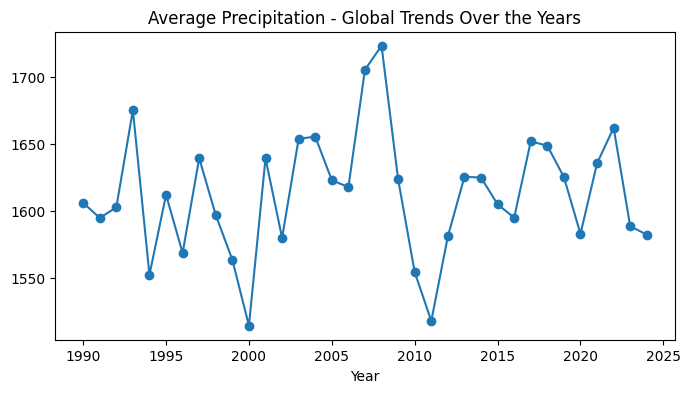

In [57]:
data.groupby('Year')['Total_Precipitation_mm'].mean().plot(kind='line', figsize=(8,4),title='Average Precipitation - Global Trends Over the Years',marker='o')

the highest average rainfall globally was recorded around 2007, and the lowest in 2024

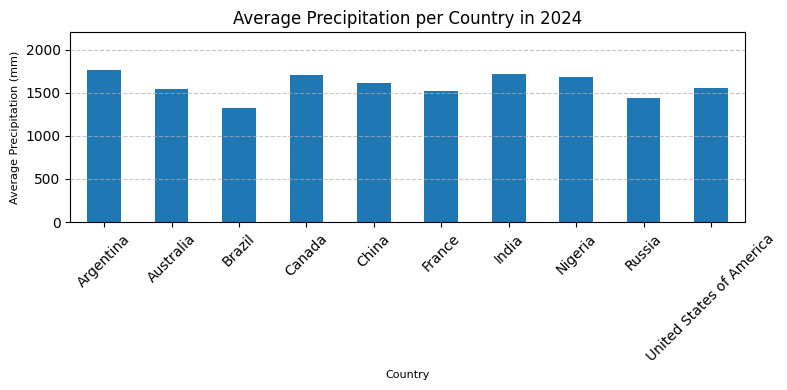

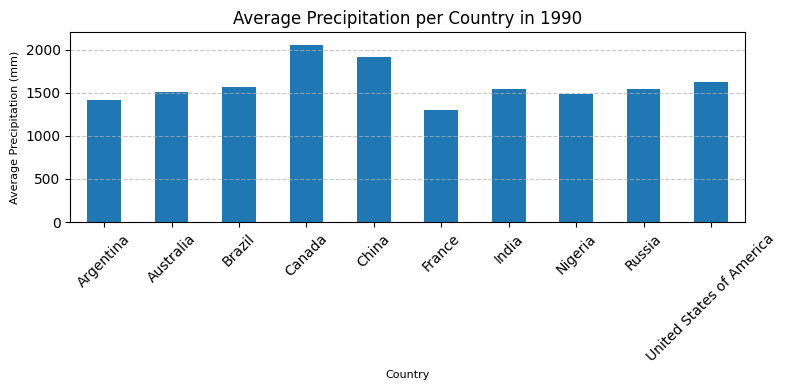

In [58]:
max_year = data['Year'].max()
min_year = data['Year'].min()

avg_precipitation_max_year = data[data['Year']==max_year].groupby('Country')['Total_Precipitation_mm'].mean()
avg_precipitation_max_year.plot(kind='bar', figsize=(8,4), title=f'Average Precipitation per Country in {max_year}')
plt.xlabel('Country', fontsize=8)
plt.ylabel('Average Precipitation (mm)', fontsize=8)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(top = 2200)
plt.tight_layout()
plt.show()

avg_precipitation_min_year = data[data['Year']==min_year].groupby('Country')['Total_Precipitation_mm'].mean()
avg_precipitation_min_year.plot(kind='bar', figsize=(8,4), title=f'Average Precipitation per Country in {min_year}')
plt.xlabel('Country', fontsize=8)
plt.ylabel('Average Precipitation (mm)', fontsize=8)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(top = 2200)
plt.tight_layout()
plt.show()

In [59]:
data.groupby('Country')['Extreme_Weather_Events'].sum().sort_values(ascending = False)

Country
United States of America    5303
Nigeria                     5216
Australia                   5192
Argentina                   5048
Canada                      4999
China                       4996
India                       4868
Brazil                      4746
France                      4729
Russia                      4712
Name: Extreme_Weather_Events, dtype: int64

In [60]:
q1_weather_events = data['Extreme_Weather_Events'].quantile(0.25)
q3_weather_events  = data['Extreme_Weather_Events'].quantile(0.75)
iqr_weather_events  = q3_weather_events  - q1_weather_events 
outliers_weather_events = data[(data['Extreme_Weather_Events'] < q1_weather_events - 1.5*iqr_weather_events) 
                   | (data['Extreme_Weather_Events'] > q3_weather_events  + 1.5*iqr_weather_events)]
print(outliers_weather_events)

Empty DataFrame
Columns: [Year, Country, Region, Crop_Type, Average_Temperature_C, Total_Precipitation_mm, CO2_Emissions_MT, Crop_Yield_MT_per_HA, Extreme_Weather_Events, Irrigation_Access_%, Pesticide_Use_KG_per_HA, Fertilizer_Use_KG_per_HA, Soil_Health_Index, Adaptation_Strategies, Economic_Impact_Million_USD, Continent, Latitude, Longitude]
Index: []


<Axes: >

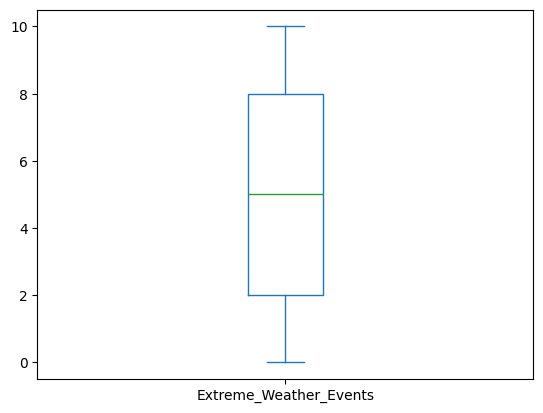

In [61]:
data['Extreme_Weather_Events'].plot(kind='box')

No outliers here in Extreme Weahther Events column

<Axes: title={'center': 'Number of Extreme Weather Events Over the Years'}, xlabel='Year'>

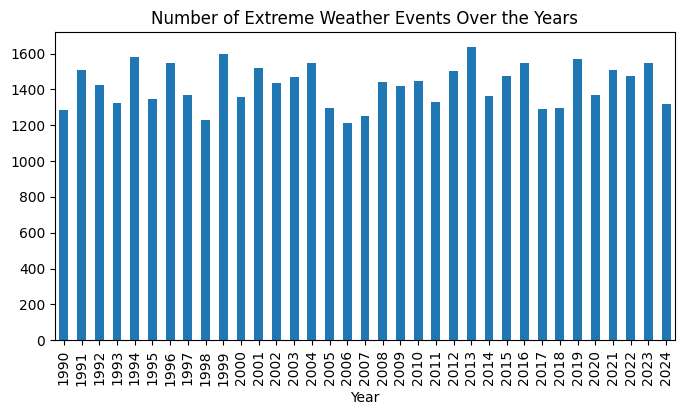

In [62]:
data.groupby('Year')['Extreme_Weather_Events'].sum().plot(kind='bar', figsize=(8,4), title = 'Number of Extreme Weather Events Over the Years' )

In [90]:
print(data.groupby('Year')['Extreme_Weather_Events'].sum().min())

1210


In [91]:
print(data.groupby('Year')['Extreme_Weather_Events'].sum().max())

1637


<Axes: >

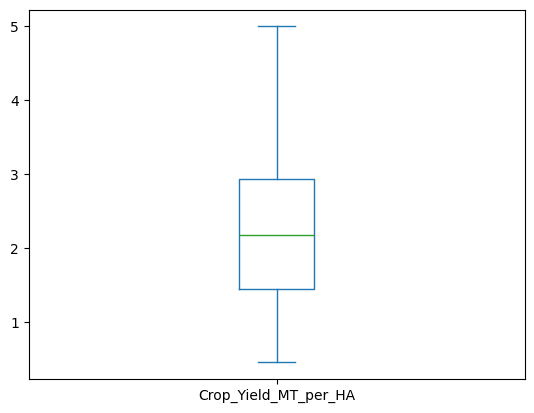

In [64]:
data['Crop_Yield_MT_per_HA'].plot(kind='box')

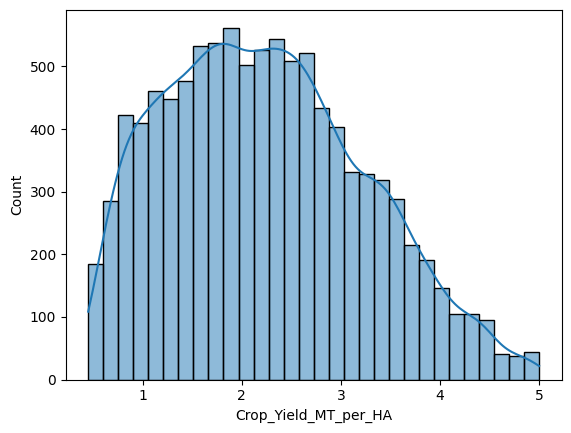

In [65]:
sns.histplot(data['Crop_Yield_MT_per_HA'], bins=30, kde=True)
plt.show()

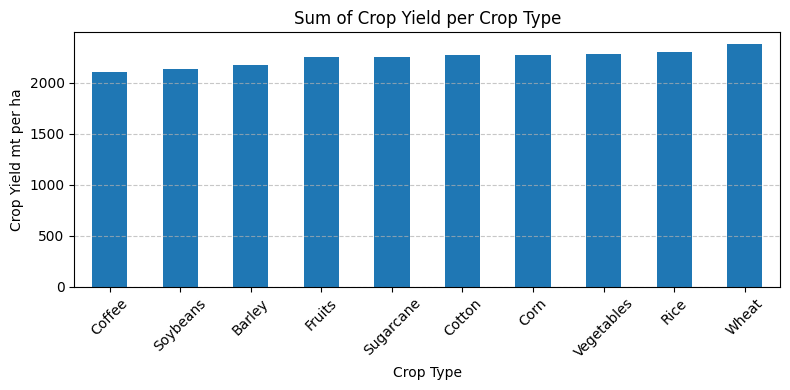

In [66]:
data.groupby('Crop_Type')['Crop_Yield_MT_per_HA'].sum().sort_values().plot(kind='bar',figsize=(8,4), title = 'Sum of Crop Yield per Crop Type')
plt.xlabel('Crop Type')
plt.xticks(rotation = 45)
plt.ylabel('Crop Yield mt per ha')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

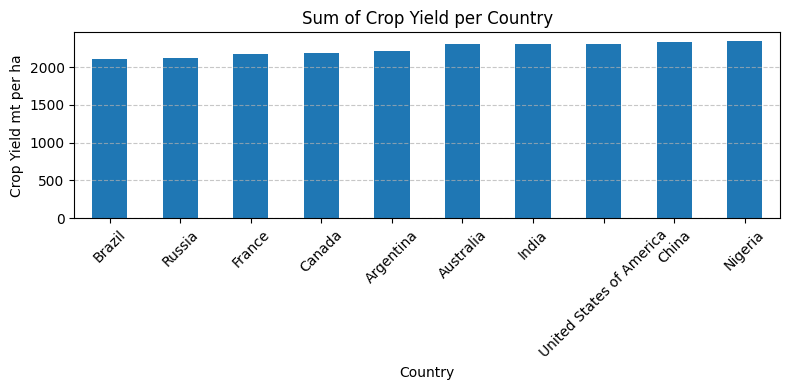

In [67]:
data.groupby('Country')['Crop_Yield_MT_per_HA'].sum().sort_values().plot(kind='bar',figsize=(8,4), title = 'Sum of Crop Yield per Country')
plt.xlabel('Country')
plt.xticks(rotation = 45)
plt.ylabel('Crop Yield mt per ha')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: >

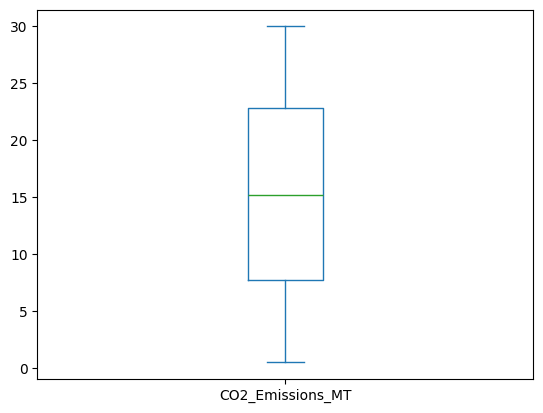

In [68]:
data['CO2_Emissions_MT'].plot(kind='box')

Text(0, 0.5, 'CO2 Emissions')

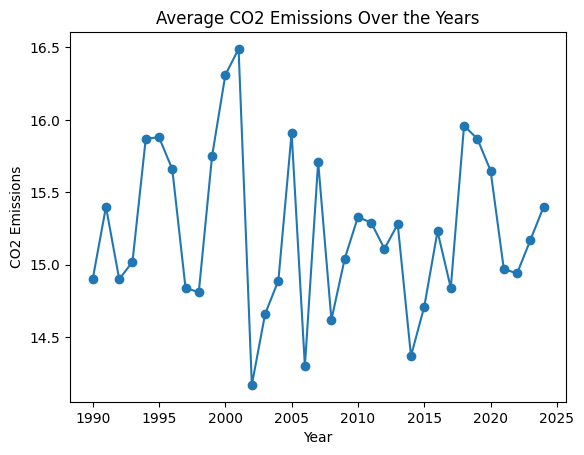

In [69]:
round(data.groupby('Year')['CO2_Emissions_MT'].mean(),2).plot(title='Average CO2 Emissions Over the Years',marker='o')
plt.ylabel('CO2 Emissions')

In [70]:
round(data.groupby('Country')['CO2_Emissions_MT'].mean(),2).sort_values()

Country
Nigeria                     14.90
Brazil                      15.02
China                       15.03
India                       15.08
Russia                      15.22
United States of America    15.36
Argentina                   15.37
Australia                   15.40
France                      15.47
Canada                      15.64
Name: CO2_Emissions_MT, dtype: float64

In [71]:
round(data.groupby(['Country', 'Region'])['CO2_Emissions_MT'].mean(),2).sort_values()

Country                   Region                    
Nigeria                   South East                    14.12
Brazil                    North                         14.33
Nigeria                   South West                    14.44
India                     Tamil Nadu                    14.49
Russia                    Central                       14.49
China                     South                         14.51
                          East                          14.71
Australia                 Western Australia             14.71
United States of America  West                          14.77
                          Northeast                     14.79
India                     West Bengal                   14.93
Argentina                 Pampas                        14.97
China                     Central                       14.97
Brazil                    South                         15.17
Russia                    Volga                         15.21
Brazil           

Axes(0.125,0.11;0.775x0.77)


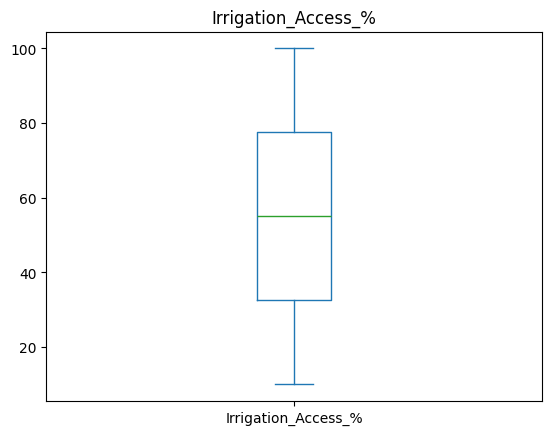

Axes(0.125,0.11;0.775x0.77)


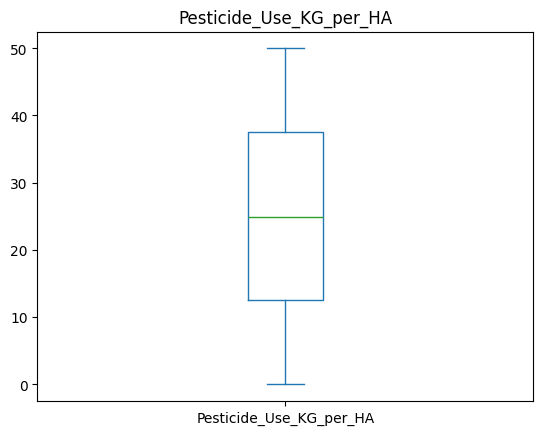

Axes(0.125,0.11;0.775x0.77)


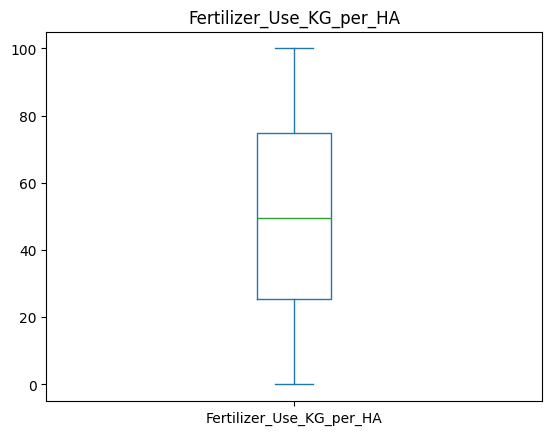

Axes(0.125,0.11;0.775x0.77)


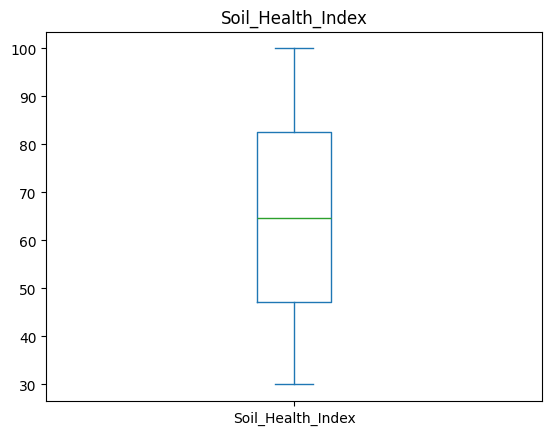

In [72]:
for col in data[['Irrigation_Access_%', 'Pesticide_Use_KG_per_HA','Fertilizer_Use_KG_per_HA','Soil_Health_Index']]:
    print(data[col].plot(kind='box', title = col))
    plt.show()

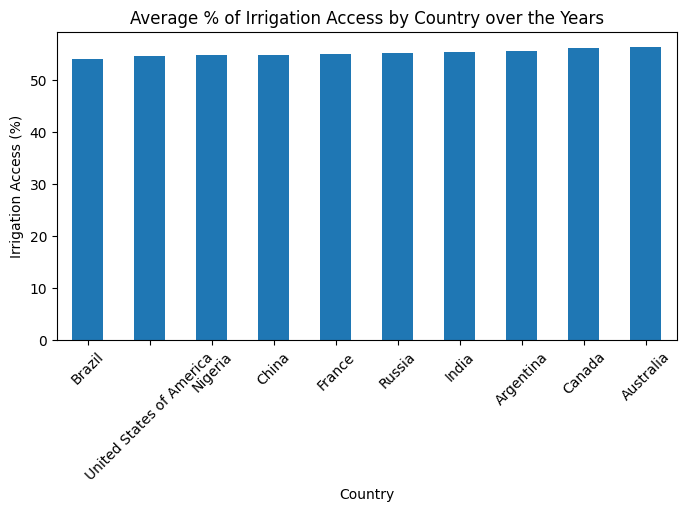

In [73]:
data.groupby('Country')['Irrigation_Access_%'].mean().sort_values().plot(kind='bar', figsize= (8,4), title = 'Average % of Irrigation Access by Country over the Years')
plt.xlabel('Country')
plt.ylabel('Irrigation Access (%)')
plt.xticks(rotation=45)
plt.show()

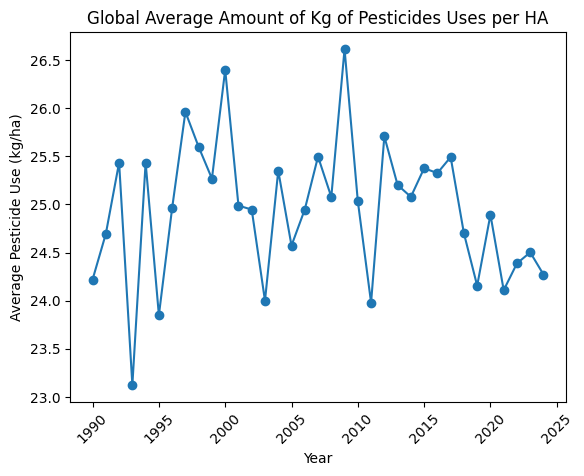

In [74]:
data.groupby('Year')['Pesticide_Use_KG_per_HA'].mean().plot(kind='line', title = 'Global Average Amount of Kg of Pesticides Uses per HA', marker = 'o')
plt.xlabel('Year')
plt.ylabel('Average Pesticide Use (kg/ha)')
plt.xticks(rotation=45)
plt.show()

<Axes: title={'center': 'Economic Impact Million (USD)'}>

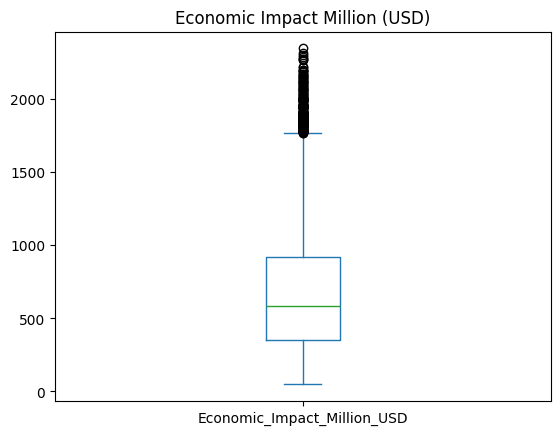

In [75]:
data['Economic_Impact_Million_USD'].plot(kind='box', title = 'Economic Impact Million (USD)')

<Axes: xlabel='Economic_Impact_Million_USD', ylabel='Count'>

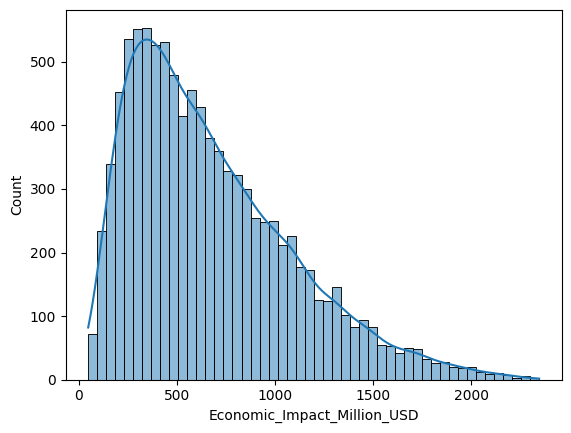

In [76]:
sns.histplot(data['Economic_Impact_Million_USD'],bins = 50, kde = True)

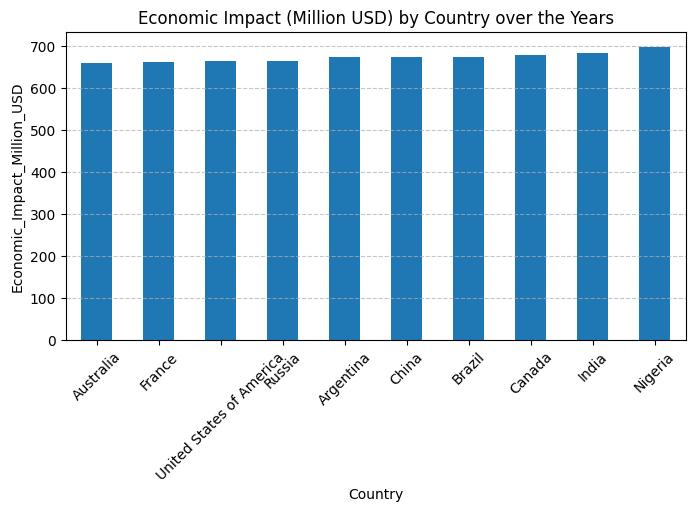

In [77]:
data.groupby('Country')['Economic_Impact_Million_USD'].mean().sort_values().plot(kind='bar', figsize= (8,4), title = 'Economic Impact (Million USD) by Country over the Years')
plt.xlabel('Country')
plt.ylabel('Economic_Impact_Million_USD')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [78]:
q1_economic_impact = data['Economic_Impact_Million_USD'].quantile(0.25)
q3_economic_impact  = data['Economic_Impact_Million_USD'].quantile(0.75)
iqr_economic_impact  = q3_economic_impact  - q1_economic_impact 
outliers_economic_impact = data[(data['Economic_Impact_Million_USD'] < q1_economic_impact - 1.5*iqr_economic_impact) 
                   | (data['Economic_Impact_Million_USD'] > q3_economic_impact  + 1.5*iqr_economic_impact)]
outliers_economic_impact.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Continent,Latitude,Longitude
19,2015,Russia,Siberian,Cotton,19.20,1086.11,23.38,3.987,4,47.81,29.58,24.76,82.85,Organic Farming,1805.57,Europe,61.961663,96.803318
143,2016,Nigeria,North Central,Corn,10.21,1705.08,7.53,4.640,1,62.81,24.76,37.48,39.89,Drought-resistant Crops,2145.28,Africa,9.548318,7.995128
218,2019,Argentina,Patagonia,Wheat,17.60,2432.88,14.56,4.870,10,73.27,20.18,6.68,71.26,Organic Farming,1853.02,South America,-35.446821,-65.175361
229,2011,Russia,Siberian,Soybeans,12.15,212.75,10.89,3.807,1,17.25,36.26,27.52,54.25,Crop Rotation,1843.68,Europe,61.961663,96.803318
233,2012,United States of America,South,Rice,11.88,1364.47,8.22,4.180,4,68.36,32.53,71.58,78.06,Water Management,1787.22,North America,45.705628,-112.599436


In [79]:
print(f'Outliers represent {outliers_economic_impact.shape[0]/data.shape[0]*100}% of whole dataset.')

Outliers represent 1.77% of whole dataset.


In [80]:
outliers_economic_impact.describe()

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD,Latitude,Longitude
count,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000
mean,2008.666667,17.187966,1689.973955,13.758249,4.249791,4.954802,57.928192,26.042203,51.084576,66.061356,1953.617401,18.174088,23.708755
std,9.806460,5.619104,742.609369,8.246003,0.348169,3.220706,26.610061,14.277577,27.986104,20.073878,137.459212,33.095908,84.421314
min,1990.000000,10.030000,212.750000,0.810000,3.560000,0.000000,10.040000,0.140000,0.050000,30.030000,1768.290000,-35.446821,-112.599436
25%,2000.000000,13.350000,1159.380000,6.660000,3.996000,2.000000,33.490000,14.170000,29.090000,49.980000,1842.040000,-10.806774,-65.175361
50%,2010.000000,15.720000,1709.320000,12.500000,4.230000,4.000000,60.850000,27.450000,50.200000,66.680000,1915.270000,22.925006,7.995128
75%,2017.000000,18.870000,2279.960000,19.940000,4.464000,8.000000,80.180000,37.570000,75.860000,83.450000,2037.420000,42.460704,96.803318
max,2024.000000,34.890000,2993.260000,29.860000,5.000000,10.000000,99.190000,49.680000,99.790000,99.800000,2346.470000,61.961663,134.502775


In [81]:
data.describe()

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD,Latitude,Longitude
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2007.088700,15.241299,1611.663834,15.246608,2.240017,4.980900,55.248332,24.955735,49.973708,64.901278,674.269658,20.810183,9.894541
std,10.084245,11.466955,805.016815,8.589423,0.998342,3.165808,25.988305,14.490962,28.711027,20.195882,414.591431,33.222214,85.904952
min,1990.000000,-4.990000,200.150000,0.500000,0.450000,0.000000,10.010000,0.000000,0.010000,30.000000,47.840000,-35.446821,-112.599436
25%,1999.000000,5.430000,925.697500,7.760000,1.449000,2.000000,32.677500,12.527500,25.390000,47.235000,350.545000,-10.806774,-65.175361
50%,2007.000000,15.175000,1611.160000,15.200000,2.170000,5.000000,55.175000,24.930000,49.635000,64.650000,583.920000,22.925006,7.995128
75%,2016.000000,25.340000,2306.997500,22.820000,2.930000,8.000000,77.582500,37.470000,74.825000,82.472500,917.505000,45.705628,96.803318
max,2024.000000,35.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,2346.470000,61.961663,134.502775


In [82]:
data['high impact'] = data['Economic_Impact_Million_USD'] > q3_economic_impact  + 1.5*iqr_economic_impact

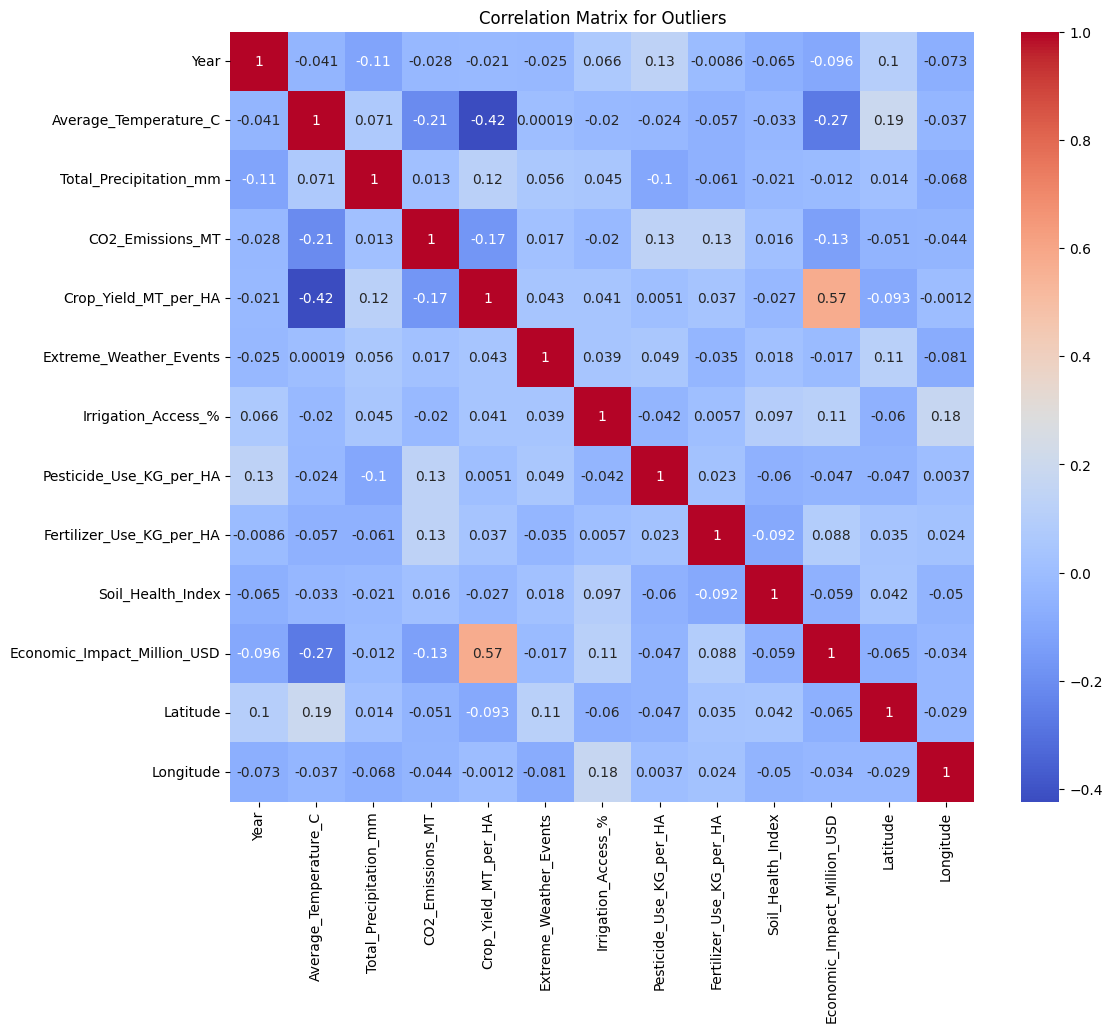

In [83]:
corr2 = outliers_economic_impact.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr2, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Outliers')
plt.show()

In [84]:
# Check if any particular year or country contributed specifically to the outliers
print(f'Number of countries with outstanding values: {len(outliers_economic_impact['Country'].unique())}')
print(f'Number of countries in dataset: {len(data['Country'].unique())}')

print(f'Number of years with outstanding values: {len(outliers_economic_impact['Year'].unique())}')
print(f'Number of years in dataset: {len(data['Year'].unique())}')

Number of countries with outstanding values: 10
Number of countries in dataset: 10
Number of years with outstanding values: 35
Number of years in dataset: 35


Check if any countries have the same latitude and if this gives any patterns:

In [85]:
data['lat_band'] = pd.cut(data['Latitude'], bins=range(-90, 91, 10))
data.groupby('lat_band')['Country'].apply(lambda x: x.unique())

lat_band
(-40, -30]                           [Argentina]
(-30, -20]                           [Australia]
(-20, -10]                              [Brazil]
(0, 10]                                [Nigeria]
(20, 30]                                 [India]
(30, 40]                                 [China]
(40, 50]      [France, United States of America]
(60, 70]                        [Canada, Russia]
Name: Country, dtype: object

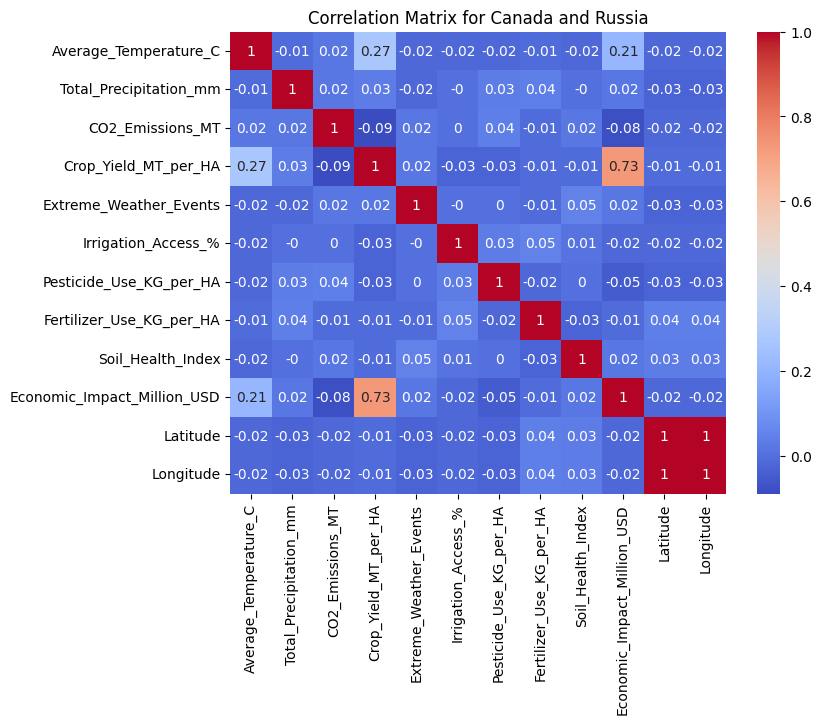

In [86]:
corr3 = (data[data['Country'].isin(['Russia', 'Canada'])].select_dtypes(include='number').drop(columns=['Year']).corr().round(2))
plt.figure(figsize=(8,6))
sns.heatmap(corr3, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Canada and Russia')
plt.show()

In [87]:
data['lat_band'] = pd.cut(data['Latitude'], bins=range(-90, 91, 40))
data.groupby('lat_band')['Country'].apply(lambda x: x.unique())

lat_band
(-50, -10]                       [Argentina, Australia, Brazil]
(-10, 30]                                      [India, Nigeria]
(30, 70]      [China, France, Canada, United States of Ameri...
Name: Country, dtype: object

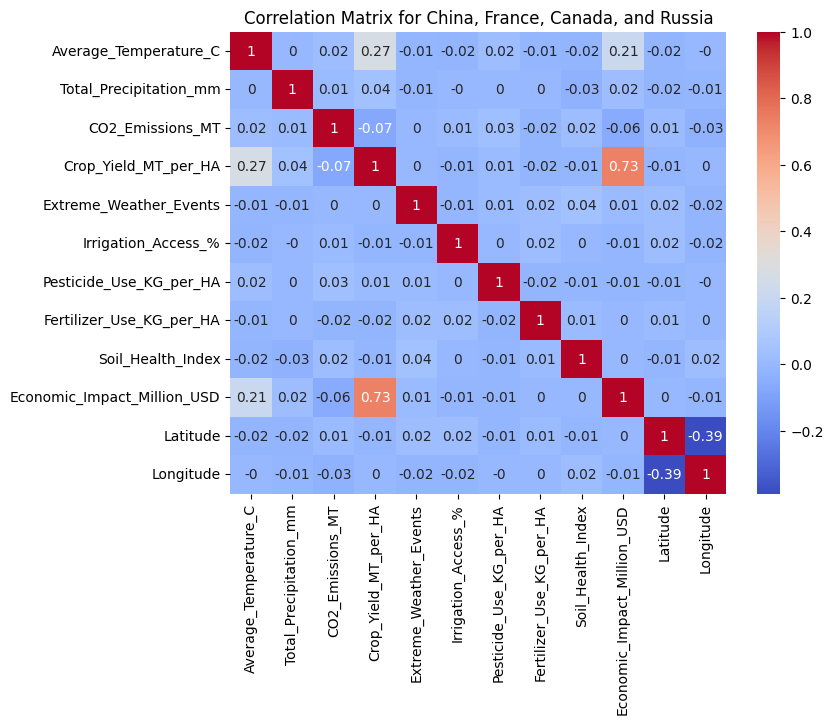

In [88]:
corr = data[data['Country'].isin(['China', 'France', 'Canada', 'Russia'])].select_dtypes(include='number').drop(columns=['Year']).corr().round(2)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for China, France, Canada, and Russia')
plt.show()

### Machine Learning Section

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
categorical_cols = ['Crop_Type', 'Adaptation_Strategies', 'Country','Continent']
ohe = OneHotEncoder(sparse_output=False)
ohe_array = ohe.fit_transform(data[categorical_cols])
#???

In [ ]:
# Converting categorical values ​​to numeric values
data = pd.get_dummies(data, columns=['Crop_Type', 'Adaptation_Strategies', 'Country','Continent'])

In [ ]:
data

,Year,Region,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,...,Country_India,Country_Nigeria,Country_Russia,Country_United States of America,Continent_Africa,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America
0,2001,West Bengal,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,...,True,False,False,False,False,True,False,False,False,False
1,2024,North,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,...,False,False,False,False,False,True,False,False,False,False
2,2001,Ile-de-France,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,...,False,False,False,False,False,False,True,False,False,False
3,2001,Prairies,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,...,False,False,False,False,False,False,False,True,False,False
4,1998,Tamil Nadu,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2022,Nouvelle-Aquitaine,30.48,685.93,17.64,3.033,9,27.56,41.96,10.95,...,False,False,False,False,False,False,True,False,False,False
9996,1999,Queensland,9.53,2560.38,10.68,2.560,4,77.02,5.45,82.32,...,False,False,False,False,False,False,False,False,True,False
9997,2000,Patagonia,31.92,357.76,26.01,1.161,10,78.53,11.94,26.00,...,False,False,False,False,False,False,False,False,False,True
9998,1996,Southeast,13.95,1549.52,17.31,3.348,2,42.65,44.71,25.07,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
# Changing the category to the target average for a column with multiple categories (Region - 34)
encoder = ce.TargetEncoder(cols=['Region'])
data['Region_enc'] = encoder.fit_transform(data['Region'], data['Economic_Impact_Million_USD'])
data = data.drop(columns=['Region', 'lat_band'])

In [ ]:
X = pd.DataFrame(data.drop(columns=['Economic_Impact_Million_USD']))
#y = pd.Series(data['Economic_Impact_Million_USD'])
#y = np.log1p(data['Economic_Impact_Million_USD'])
y =  (data['Economic_Impact_Million_USD'] - data['Economic_Impact_Million_USD'].min()) / (data['Economic_Impact_Million_USD'].max() - data['Economic_Impact_Million_USD'].min())

print(X.dtypes.unique())

[dtype('int64') dtype('float64') dtype('bool')]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)

y_pred_linear = model_linear.predict(X_test_scaled)
print("MSE:", mean_squared_error(y_test, y_pred_linear))
print("RMSE:", root_mean_squared_error(y_test, y_pred_linear))
print("MAE:", mean_absolute_error(y_test, y_pred_linear))
print("R2:", r2_score(y_test, y_pred_linear))

MSE: 0.013767329261650744
RMSE: 0.11733426294842758
MAE: 0.0936116116243887
R2: 0.5967070030733006


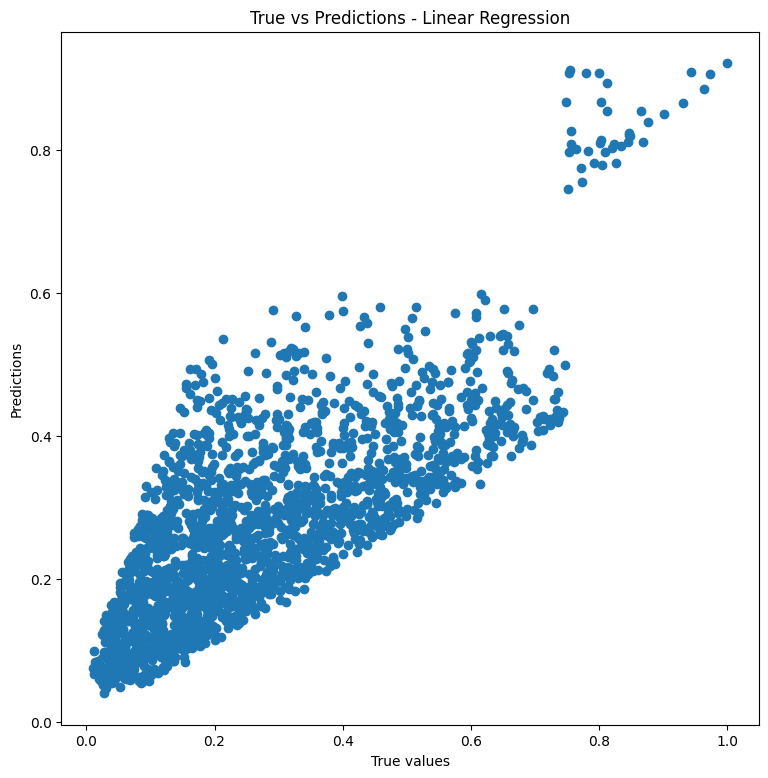

In [ ]:
plt.scatter(y_test, y_pred_linear)
plt.title("True vs Predictions - Linear Regression")
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.show()

In [ ]:
# Searching for the best hyperparameters 
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1
)

search.fit(X_train, y_train)

print(search.best_params_)
model_xgb = search.best_estimator_
y_pred_xgb = model_xgb.predict(X_test)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [ ]:
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", root_mean_squared_error(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2:", r2_score(y_test, y_pred_xgb))

MSE: 0.01374208673852283
RMSE: 0.11722664687912399
MAE: 0.09378560499389134
R2: 0.597446444442703


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

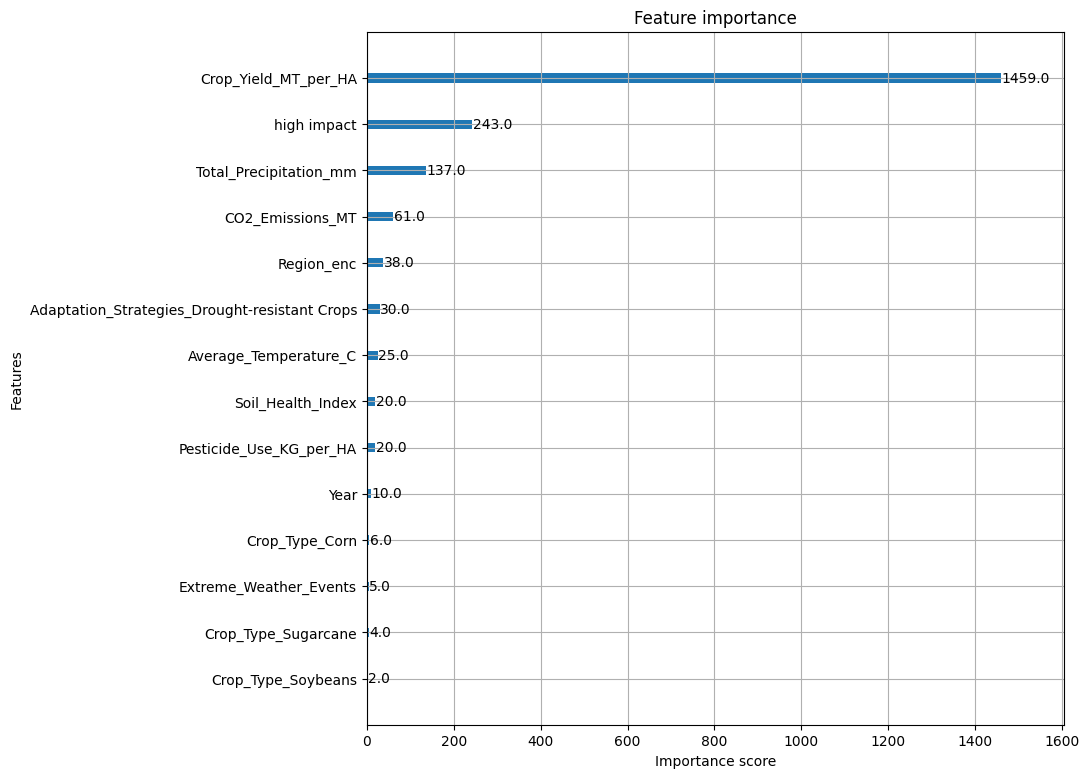

In [ ]:
xgboost.plot_importance(model_xgb)

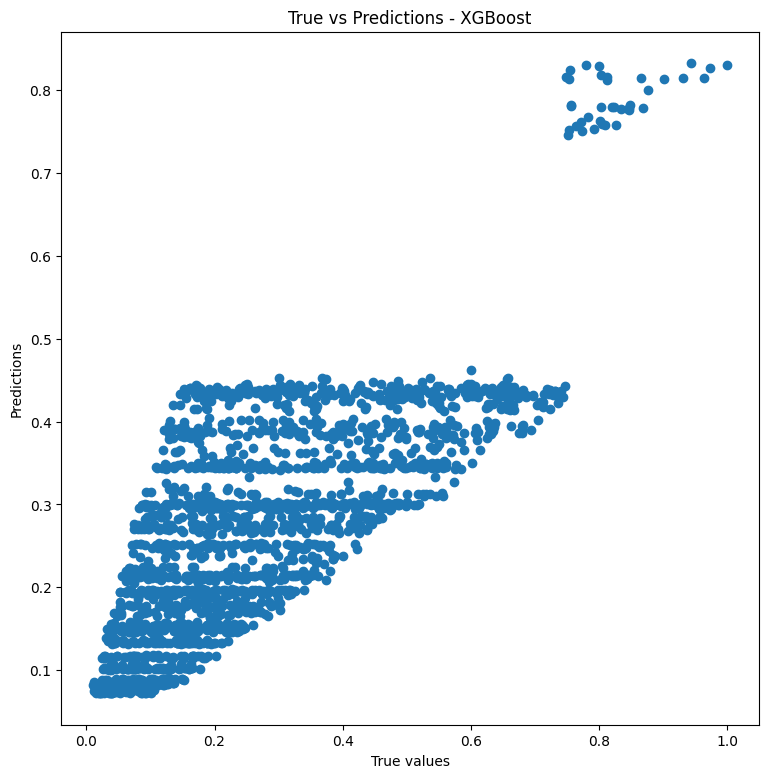

In [ ]:
plt.scatter(y_test, y_pred_xgb)
plt.title("True vs Predictions - XGBoost")
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "RMSE": [
        root_mean_squared_error(y_test, y_pred_linear),
        root_mean_squared_error(y_test, y_pred_xgb)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "R2": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_xgb)
    ]
})

print(results)

               Model      RMSE       MAE        R2
0  Linear Regression  0.117334  0.093612  0.596707
1            XGBoost  0.117227  0.093786  0.597446


The XGBoost model is better than Linear Regression across all evaluation metrics, indicating better overall predictive accuracy.

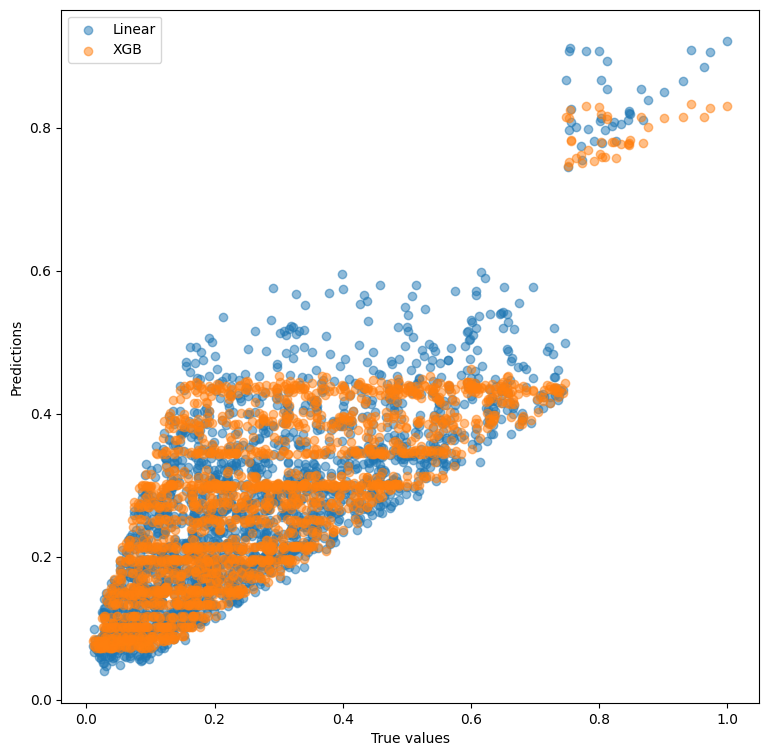

In [ ]:
plt.scatter(y_test, y_pred_linear, alpha=0.5)
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.legend(["Linear", "XGB"])
plt.show()

- XGBoost predictions are more concentrated so the model is more stable and has lower variance, however, it tends to underestimate higher values
- Linear Regression captures extreme values better, but has a wider spread of errors, making it less reliable overall

Conclusion:
XGBoost is the better model due to its higher accuracy and stability, but it could be improved further by addressing its tendency to underestimate large target values.